<a href="https://colab.research.google.com/github/shaik-naaziya-3/demo-repo/blob/main/House_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving house_price_dataset.csv to house_price_dataset.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('house_price_dataset.csv')

df.head()

,Area_sqft,Bedrooms,Bathrooms,Parking,House_Age,Location_Rating,Distance_City_km,Price
0,3974,4,1,0,9,4,26,19053000
1,1660,5,4,0,5,3,21,9640000
2,2094,1,1,2,24,7,18,10233000
3,1930,5,3,2,29,8,13,11245000
4,1895,5,1,3,17,4,11,10497500


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Area_sqft         100 non-null    int64
 1   Bedrooms          100 non-null    int64
 2   Bathrooms         100 non-null    int64
 3   Parking           100 non-null    int64
 4   House_Age         100 non-null    int64
 5   Location_Rating   100 non-null    int64
 6   Distance_City_km  100 non-null    int64
 7   Price             100 non-null    int64
dtypes: int64(8)
memory usage: 6.4 KB


In [ ]:
df.describe()

,Area_sqft,Bedrooms,Bathrooms,Parking,House_Age,Location_Rating,Distance_City_km,Price
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,1.000000e+02
mean,2472.660000,2.910000,2.680000,1.650000,15.730000,5.500000,15.960000,1.289317e+07
std,918.624094,1.464013,1.144861,1.192358,8.819005,3.125328,7.825005,4.125033e+06
min,821.000000,1.000000,1.000000,0.000000,1.000000,1.000000,3.000000,4.947000e+06
25%,1735.750000,1.000000,2.000000,1.000000,8.000000,3.000000,9.750000,9.635125e+06
50%,2382.000000,3.000000,3.000000,2.000000,16.500000,5.000000,16.500000,1.255750e+07
75%,3233.500000,4.000000,4.000000,3.000000,23.000000,8.000000,23.000000,1.648800e+07
max,3974.000000,5.000000,4.000000,3.000000,29.000000,10.000000,29.000000,2.077250e+07


In [ ]:
df.isnull().sum()

,0
Area_sqft,0
Bedrooms,0
Bathrooms,0
Parking,0
House_Age,0
Location_Rating,0
Distance_City_km,0
Price,0


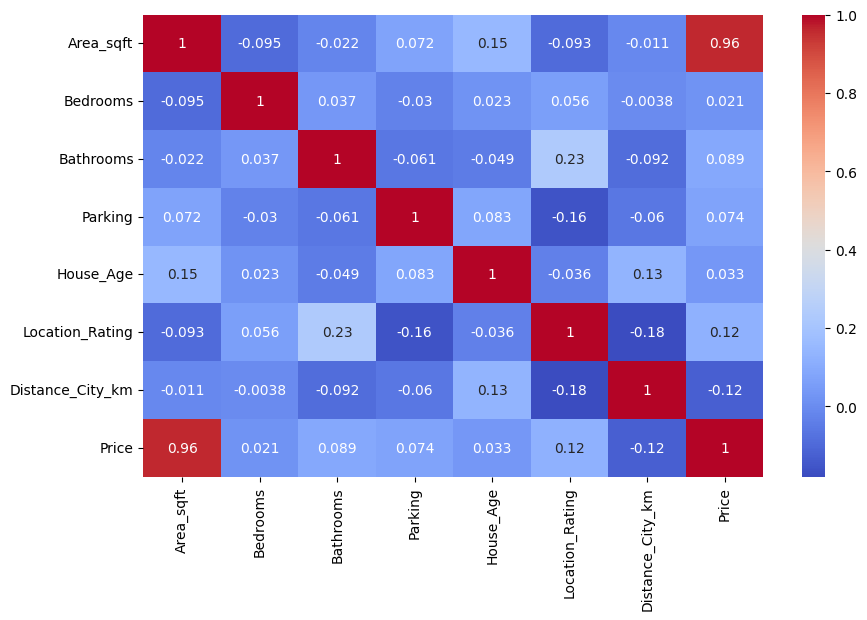

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [ ]:
X = df.drop('Price', axis=1)
y = df['Price']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 2.514570951461792e-09
MSE: 8.153200337090994e-18
RMSE: 2.855380944303403e-09
R2 Score: 1.0


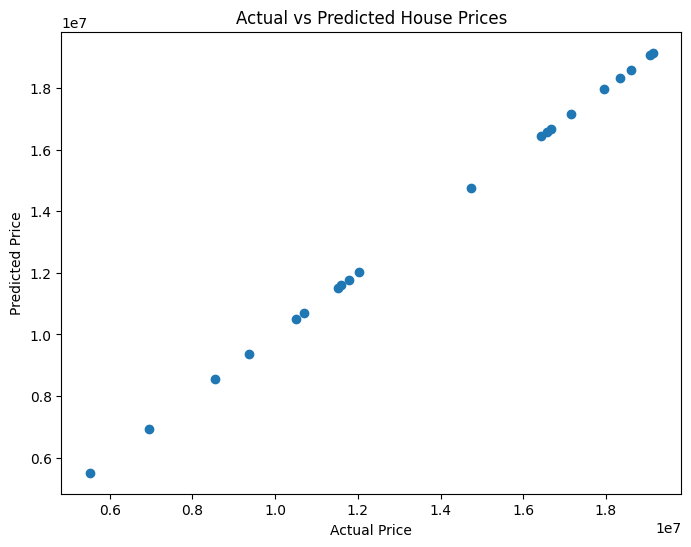

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

In [ ]:
sample_house = [[2000, 3, 2, 1, 5, 8, 10]]

predicted_price = model.predict(sample_house)

print("Predicted Price:", predicted_price[0])

Predicted Price: 11900000.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
import pickle

pickle.dump(model, open('house_price_model.pkl', 'wb'))

In [ ]:
from google.colab import files

files.download('house_price_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>